In [1]:
#Importing Dependencies
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

###Data Preparation
Files loaded into a database using Duckdb and Python.

In [20]:
con = duckdb.connect()

con.execute("""
CREATE TABLE person AS SELECT * FROM 'person.parquet';
""")

con.execute("""
CREATE TABLE visit_occurrence AS SELECT * FROM 'visit_occurrence.parquet';
""")

con.execute("""
CREATE TABLE hospital_visits AS SELECT * FROM 'hospital_visits.parquet';
""")

con.execute("""
CREATE TABLE readmission_features AS SELECT * FROM 'readmission_features.parquet';
""")

con.execute("""
CREATE TABLE procedures AS SELECT * FROM 'procedures.parquet';
""")

con.execute("""
CREATE TABLE conditions AS SELECT * FROM 'conditions.parquet';
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [26]:
conditions_agg = con.execute("""
SELECT
    visit_occurrence_id,
    COUNT(*) AS num_conditions,
    COUNT(DISTINCT condition_concept_id) AS unique_conditions
FROM conditions
GROUP BY visit_occurrence_id
""").df()

In [27]:
procedures_agg = con.execute("""
SELECT
    visit_occurrence_id,
    COUNT(*) AS num_procedures,
    COUNT(DISTINCT procedure_concept_id) AS unique_procedures
FROM procedures
GROUP BY visit_occurrence_id
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

###Queries
Increasing in complexity

In [21]:
df1 = con.execute("""
SELECT
    v.visit_occurrence_id,
    v.person_id,
    p.gender_concept_id,
    p.race_concept_id,
    v.visit_start_date
FROM visit_occurrence v
JOIN person p
ON v.person_id = p.person_id
WHERE v.visit_concept_id = 9201;
""").df()

df1.head()

,visit_occurrence_id,person_id,gender_concept_id,race_concept_id,visit_start_date
0,75079,76630,8507,8527,1918-11-22
1,109405,107193,8507,8527,1918-11-25
2,89890,71521,8532,0,1918-11-30
3,96263,88173,8507,8527,1918-12-11
4,72518,1088,8507,8527,1918-12-15


In [22]:
df2 = con.execute("""
SELECT
    person_id,
    COUNT(*) AS total_visits,
    MIN(visit_start_date) AS first_visit,
    MAX(visit_start_date) AS last_visit
FROM visit_occurrence
GROUP BY person_id;
""").df()

df2.head()

,person_id,total_visits,first_visit,last_visit
0,7982,20,1970-06-08,2006-05-11
1,4377,82,1945-07-04,1972-03-08
2,48996,31,1929-01-13,1971-06-03
3,76523,29,1963-12-16,1995-05-15
4,104925,39,1970-06-08,2019-03-25


In [23]:
df3 = con.execute("""
SELECT
    person_id,
    visit_occurrence_id,
    visit_start_date,
    LAG(visit_start_date) OVER (
        PARTITION BY person_id
        ORDER BY visit_start_date
    ) AS prev_visit
FROM visit_occurrence;
""").df()

df3.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,person_id,visit_occurrence_id,visit_start_date,prev_visit
0,24,346306,1999-08-18,None
1,24,346261,2003-08-23,1999-08-18
2,24,346262,2009-05-19,2003-08-23
3,24,346245,2009-05-20,2009-05-19
4,24,346263,2009-08-19,2009-05-20


In [24]:
df4 = con.execute("""
SELECT
    f.person_id,
    f.AGE,
    f.PRIOR_ADMISSIONS,
    f.READMIT_30,
    agg.total_visits
FROM readmission_features f
JOIN (
    SELECT person_id, COUNT(*) AS total_visits
    FROM visit_occurrence
    GROUP BY person_id
) agg
ON f.person_id = agg.person_id;
""").df()

df4.head()

,person_id,AGE,PRIOR_ADMISSIONS,READMIT_30,total_visits
0,103649,79,17,1,151
1,103649,79,18,0,151
2,103649,79,19,1,151
3,103649,79,20,1,151
4,103649,79,21,0,151


In [25]:
df = con.execute("""
SELECT
    f.person_id,
    f.READMIT_30,
    f.AGE,
    f.PRIOR_ADMISSIONS,
    agg.total_visits,
    p.gender_concept_id,
    p.race_concept_id
FROM readmission_features f
JOIN person p
    ON f.person_id = p.person_id
JOIN (
    SELECT person_id, COUNT(*) AS total_visits
    FROM visit_occurrence
    GROUP BY person_id
) agg
ON f.person_id = agg.person_id;
""").df()

df.head()

,person_id,READMIT_30,AGE,PRIOR_ADMISSIONS,total_visits,gender_concept_id,race_concept_id
0,103649,1,79,17,151,8532,8527
1,103649,0,79,18,151,8532,8527
2,103649,1,79,19,151,8532,8527
3,103649,1,79,20,151,8532,8527
4,103649,0,79,21,151,8532,8527


In [57]:
dfmod = con.execute("""
SELECT
    f.visit_occurrence_id,
    f.person_id,
    f.READMIT_30,
    f.AGE,
    f.PRIOR_ADMISSIONS,
    agg.total_visits,
    p.gender_concept_id,
    p.race_concept_id,

    COALESCE(c.num_conditions, 0) AS num_conditions,
    COALESCE(c.unique_conditions, 0) AS unique_conditions,

    COALESCE(pr.num_procedures, 0) AS num_procedures,
    COALESCE(pr.unique_procedures, 0) AS unique_procedures

FROM readmission_features f

JOIN person p
    ON f.person_id = p.person_id

JOIN (
    SELECT person_id, COUNT(*) AS total_visits
    FROM visit_occurrence
    GROUP BY person_id
) agg
    ON f.person_id = agg.person_id

LEFT JOIN (
    SELECT
        visit_occurrence_id,
        COUNT(*) AS num_conditions,
        COUNT(DISTINCT condition_concept_id) AS unique_conditions
    FROM conditions
    GROUP BY visit_occurrence_id
) c
    ON f.visit_occurrence_id = c.visit_occurrence_id

LEFT JOIN (
    SELECT
        visit_occurrence_id,
        COUNT(*) AS num_procedures,
        COUNT(DISTINCT procedure_concept_id) AS unique_procedures
    FROM procedures
    GROUP BY visit_occurrence_id
) pr
    ON f.visit_occurrence_id = pr.visit_occurrence_id;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [41]:
dfmod.head()

,visit_occurrence_id,person_id,READMIT_30,AGE,PRIOR_ADMISSIONS,total_visits,gender_concept_id,race_concept_id,num_conditions,unique_conditions,num_procedures,unique_procedures
0,2338,3626,0,50,0,54,8532,8527,0,0,4,1
1,91403,3632,0,43,2,39,8532,8527,0,0,4,1
2,1433,3636,0,23,0,14,8507,8527,3,1,4,1
3,76258,3646,0,115,10,56,8507,8527,0,0,4,1
4,27515,3646,0,115,8,56,8507,8527,0,0,4,1


In [34]:
dfmod["visit_occurrence_id"].nunique() == len(dfmod)

True

In [33]:
dfmod['READMIT_30'].value_counts()

,count
READMIT_30,
0,106480
1,33537


###Solution Implementation
Building a Model.

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Feature Engineering
# -----------------------------
dfmod = dfmod.copy()

dfmod["complexity"] = dfmod["num_conditions"] + dfmod["num_procedures"]

dfmod["proc_per_condition"] = dfmod["num_procedures"] / (dfmod["num_conditions"] + 1)

dfmod["conditions_per_visit"] = dfmod["num_conditions"] / dfmod["total_visits"]

dfmod["admission_condition_interaction"] = dfmod["PRIOR_ADMISSIONS"] * dfmod["num_conditions"]

# -----------------------------
# One-hot encode categorical variables
# -----------------------------
dfmod = pd.get_dummies(
    dfmod,
    columns=["gender_concept_id", "race_concept_id"],
    drop_first=True
)

# -----------------------------
# Define features and target
# -----------------------------
target = "READMIT_30"

feature_cols = [
    "AGE",
    "PRIOR_ADMISSIONS",
    "total_visits",
    "num_conditions",
    "unique_conditions",
    "num_procedures",
    "unique_procedures",
    "complexity",
    "proc_per_condition",
    "conditions_per_visit",
    "admission_condition_interaction"
]

# Include all one-hot encoded columns automatically
categorical_cols = [col for col in dfmod.columns if col.startswith("gender_concept_id_") or col.startswith("race_concept_id_")]
feature_cols = feature_cols + categorical_cols

X = dfmod[feature_cols]
y = dfmod[target]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Train Random Forest model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# Evaluate model
# -----------------------------
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print("ROC AUC:", auc)

ROC AUC: 0.8794397175994932


In [44]:
dfmod["READMIT_30"].value_counts(normalize=True)

,proportion
READMIT_30,
0,0.760479
1,0.239521


In [59]:
train_pred = model.predict_proba(X_train)[:,1]
test_pred = model.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC:", roc_auc_score(y_test, test_pred))

Train AUC: 0.8928151079180862
Test AUC: 0.8794397175994932


Checking Train and Test AUC to ensure that the model was not way overfitting.  

### Visualization Results

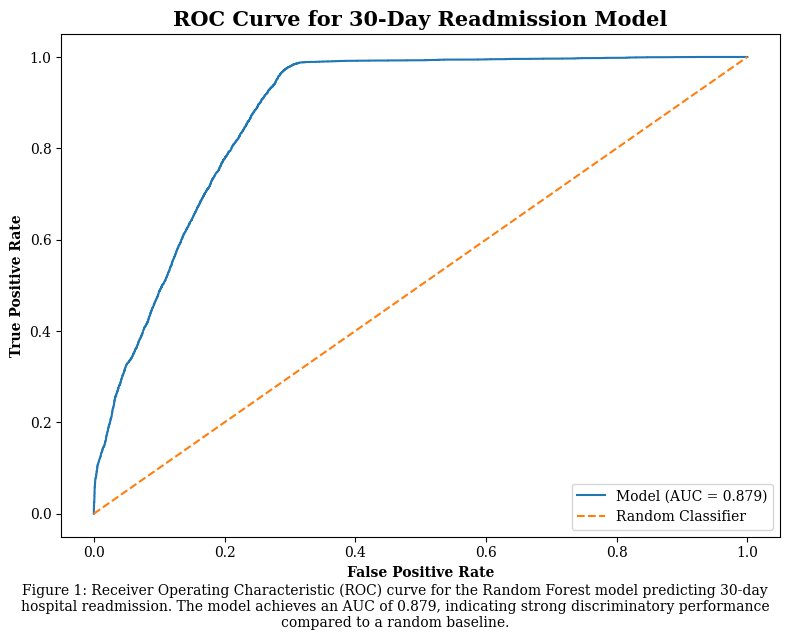

In [72]:
from sklearn.metrics import roc_curve, auc
# Set global font to Times New Roman
plt.rcParams["font.family"] = ["DejaVu Serif", "serif"]

# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate", fontweight="bold")
plt.ylabel("True Positive Rate", fontweight="bold")
plt.title("ROC Curve for 30-Day Readmission Model", fontweight="bold", fontsize = 15)
plt.legend(loc="lower right")

# Caption (publication-style)
plt.figtext(
    0.5, -0.05,
    "Figure 1: Receiver Operating Characteristic (ROC) curve for the Random Forest model predicting 30-day hospital readmission. "
    "The model achieves an AUC of {:.3f}, indicating strong discriminatory performance compared to a random baseline.".format(roc_auc),
    wrap=True,
    horizontalalignment="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

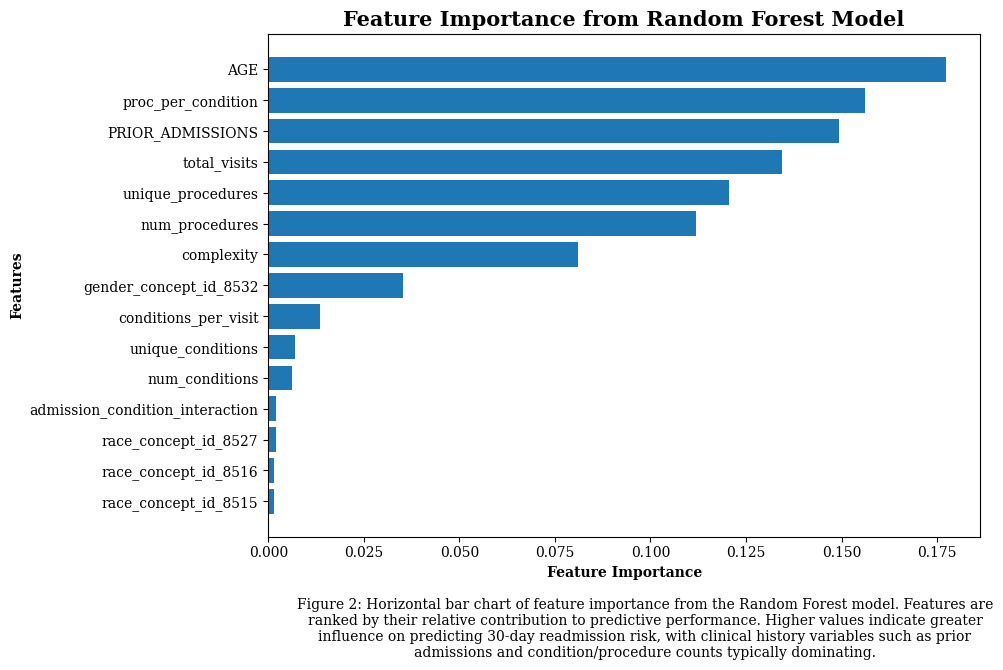

In [69]:
# Feature importance
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=True)  # ascending for horizontal plot

plt.figure(figsize=(10, 6))

# Horizontal bar chart
plt.barh(feat_imp_df["feature"], feat_imp_df["importance"])

plt.xlabel("Feature Importance", fontweight="bold")
plt.ylabel("Features", fontweight="bold")
plt.title("Feature Importance from Random Forest Model", fontweight="bold", fontsize = 15)

# Caption
plt.figtext(
    .65, -0.1,
    "Figure 2: Horizontal bar chart of feature importance from the Random Forest model. "
    "Features are ranked by their relative contribution to predictive performance. "
    "Higher values indicate greater influence on predicting 30-day readmission risk, "
    "with clinical history variables such as prior admissions and condition/procedure counts typically dominating.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

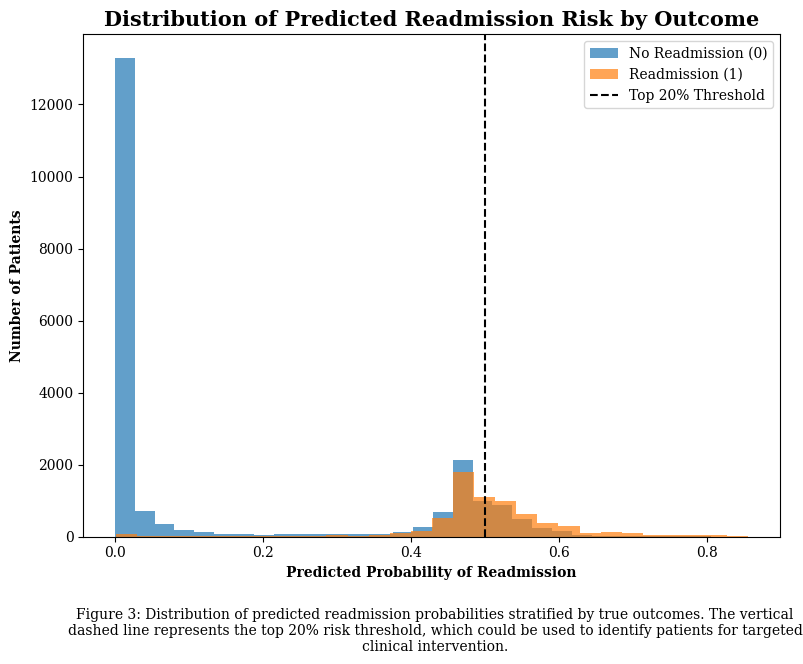

In [78]:
# Get predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Separate by actual outcome
probs_readmit = y_pred_proba[y_test == 1]
probs_no_readmit = y_pred_proba[y_test == 0]
threshold = np.percentile(y_pred_proba, 80)  # top 20% highest risk

plt.figure(figsize=(8, 6))

plt.hist(probs_no_readmit, bins=30, alpha=0.7, label="No Readmission (0)")
plt.hist(probs_readmit, bins=30, alpha=0.7, label="Readmission (1)")

plt.xlabel("Predicted Probability of Readmission", fontweight='bold')
plt.ylabel("Number of Patients", fontweight='bold')
plt.title("Distribution of Predicted Readmission Risk by Outcome", fontweight='bold', fontsize= 15)

# Vertical threshold line
plt.axvline(threshold, color='black', linestyle='--', label="Top 20% Threshold")

plt.legend()

# Caption
plt.figtext(
    0.55, -0.09,
    "Figure 3: Distribution of predicted readmission probabilities stratified by true outcomes. "
    "The vertical dashed line represents the top 20% risk threshold, which could be used to "
    "identify patients for targeted clinical intervention.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [80]:
from sklearn.metrics import precision_recall_curve

# Predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Target recall
target_recall = 0.80

# Find indices where recall >= target
valid_indices = np.where(recall >= target_recall)[0]

# Choose the threshold that gives recall just above target
idx = valid_indices[-1]  # closest to target from below

# Corresponding threshold
chosen_threshold = thresholds[idx]

print("Chosen threshold for ~80% recall:", chosen_threshold)
print("Achieved recall:", recall[idx])
print("Corresponding precision:", precision[idx])

Chosen threshold for ~80% recall: 0.46361772991666805
Achieved recall: 0.8000894454382826
Corresponding precision: 0.544762484774665


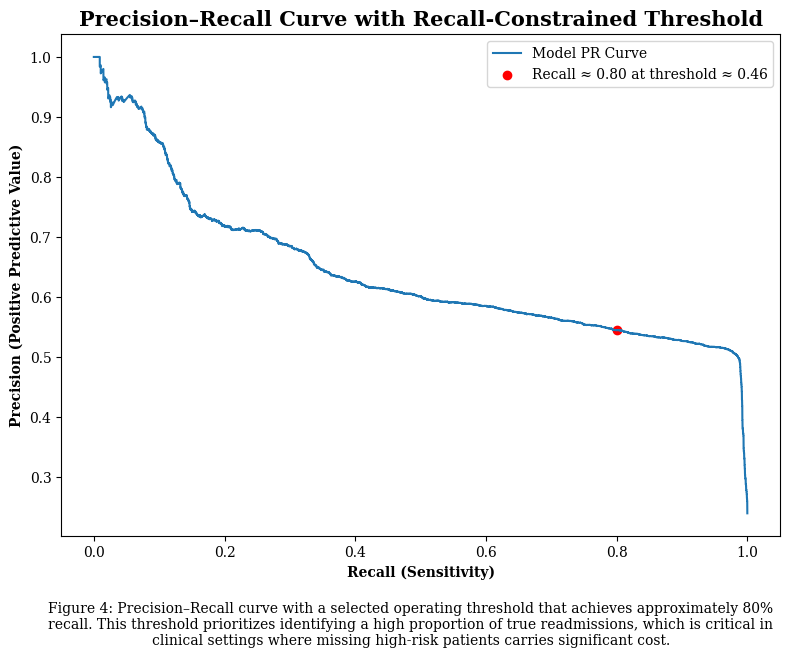

In [85]:
plt.figure(figsize=(8, 6))

# PR curve
plt.plot(recall, precision, label="Model PR Curve")

# Mark the selected threshold point
plt.scatter(recall[idx], precision[idx], color='red',
            label=f"Recall ≈ {recall[idx]:.2f} at threshold ≈ {chosen_threshold:.2f}")

plt.xlabel("Recall (Sensitivity)", fontweight='bold')
plt.ylabel("Precision (Positive Predictive Value)", fontweight='bold')
plt.title("Precision–Recall Curve with Recall-Constrained Threshold", fontweight='bold', fontsize= 15)

plt.legend()

plt.figtext(
    0.52, -0.08,
    "Figure 4: Precision–Recall curve with a selected operating threshold that achieves approximately "
    "80% recall. This threshold prioritizes identifying a high proportion of true readmissions, "
    "which is critical in clinical settings where missing high-risk patients carries significant cost.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

###Analysis Rationale
The analysis was designed to develop a predictive model for 30-day hospital readmission using structured patient-level data derived from a relational dataset. A Random Forest classifier was selected due to its ability to handle nonlinear relationships, interactions between variables, and mixed feature types without requiring extensive preprocessing or strong parametric assumptions. The dataset was constructed by joining multiple tables (e.g., patient demographics, visit history, conditions, and procedures) to ensure that each observation represents a patient visit enriched with clinically relevant context. Feature engineering focused on aggregating patient history into meaningful predictors such as prior admissions, total visits, and counts of conditions and procedures, which serve as proxies for patient complexity and healthcare utilization. Categorical variables such as race and gender were included as predictors to capture potential disparities or population-level trends. Model evaluation was performed using a train-test split to assess generalization, and ROC-AUC and Average Precision were used as primary metrics to account for class imbalance and to evaluate both ranking ability and performance on the minority class (readmissions). Visualizations provided another layer of analysis for use by healthcare workers and hospitals, the end users who would ultimately be considering implementing and using such a model in the workplace.

### Visualization Rationale
The visualizations were selected to provide both performance evaluation and interpretability from a clinical decision-making perspective. The ROC curve was used to assess the model’s ability to discriminate between readmitted and non-readmitted patients across all classification thresholds, with the AUC providing a summary measure of overall performance. In addition, the Precision–Recall curve was included as it is more informative in the presence of class imbalance, emphasizing the tradeoff between correctly identifying high-risk patients (recall) and the reliability of those predictions (precision). A risk score distribution plot was used to visualize how predicted probabilities differ between actual outcomes, allowing stakeholders to assess whether the model meaningfully separates high-risk and low-risk patients. This is particularly important in healthcare settings where prioritization of limited resources is required. Finally, a horizontal feature importance plot was used to identify the most influential predictors in the model, improving interpretability and helping clinicians understand which factors drive predictions. Together, these visualizations were chosen to balance statistical performance assessment with practical interpretability, supporting both model validation and potential real-world implementation in a hospital setting. It is important to note that in a real-world clinical setting, providers would be able to distinguish between gender and race codes as well as the procedure and condition types as they would be encoded in their own hospital system.